# Capítulo 23 — Support Vector Machines

En el capítulo anterior estudiamos Gradient Boosting, un ensamble que construye predicciones mediante correcciones sucesivas. Ahora cambiaremos de perspectiva: **Support Vector Machines (SVM)** interpreta la clasificación como un problema geométrico.

Un SVM intenta separar las clases mediante una frontera y presta especial atención a los casos cercanos a ella. En lugar de aceptar cualquier separación, busca un **margen** amplio. Cuando una recta no alcanza, los kernels permiten construir fronteras no lineales.

Comenzaremos con ejemplos bidimensionales para observar la frontera, los márgenes y los vectores de soporte. Después retomaremos **Breast Cancer Wisconsin**, mantendremos reservado el mismo conjunto de prueba de los cuadernos recientes y ajustaremos un pipeline completo sin contaminar la evaluación.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- explicar qué representan la frontera, el margen y los vectores de soporte;
- relacionar `C` con la tolerancia a errores y la complejidad;
- distinguir un kernel lineal de un kernel RBF;
- reconocer el efecto de `gamma` sobre una frontera no lineal;
- justificar por qué SVM necesita variables bien escaladas;
- incluir el escalado dentro de un `Pipeline`;
- ajustar `C`, `gamma` y el kernel mediante validación cruzada;
- interpretar `decision_function` sin confundirla con una probabilidad;
- evaluar el modelo una sola vez sobre el test final;
- reconocer ventajas y limitaciones prácticas de SVM.


## 1. Importar las herramientas

Usaremos NumPy y Pandas para organizar los resultados, Matplotlib para visualizar las fronteras y `scikit-learn` para construir pipelines, realizar validación cruzada y entrenar modelos SVM.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import (
    load_breast_cancer,
    make_blobs,
    make_circles,
    make_classification,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)


## 2. Observar la frontera y el margen

Comenzaremos con dos grupos que pueden separarse mediante una recta. Las dos variables son abstractas: solo necesitamos que cada fila sea un punto y que el color indique su clase.

Entrenaremos un SVM lineal después de estandarizar los datos. En un problema real, el escalador también debe aprender únicamente a partir del entrenamiento; aquí usamos todos los puntos porque esta primera sección es una demostración geométrica, no una evaluación de generalización.


In [2]:
X_margen, y_margen = make_blobs(
    n_samples=90,
    centers=[(-2.2, -1.2), (2.0, 1.4)],
    cluster_std=[0.72, 0.78],
    random_state=7,
)

scaler_margen = StandardScaler()
X_margen_escalado = scaler_margen.fit_transform(
    X_margen
)

svm_margen = SVC(
    kernel="linear",
    C=1.0,
)
svm_margen.fit(X_margen_escalado, y_margen)

pd.DataFrame({
    "filas": [len(X_margen)],
    "clase_0": [(y_margen == 0).sum()],
    "clase_1": [(y_margen == 1).sum()],
    "vectores_soporte": [
        svm_margen.n_support_.sum()
    ],
    "accuracy_entrenamiento": [
        svm_margen.score(
            X_margen_escalado,
            y_margen,
        )
    ],
}).round(3)


,filas,clase_0,clase_1,vectores_soporte,accuracy_entrenamiento
0,90,45,45,4,1.0


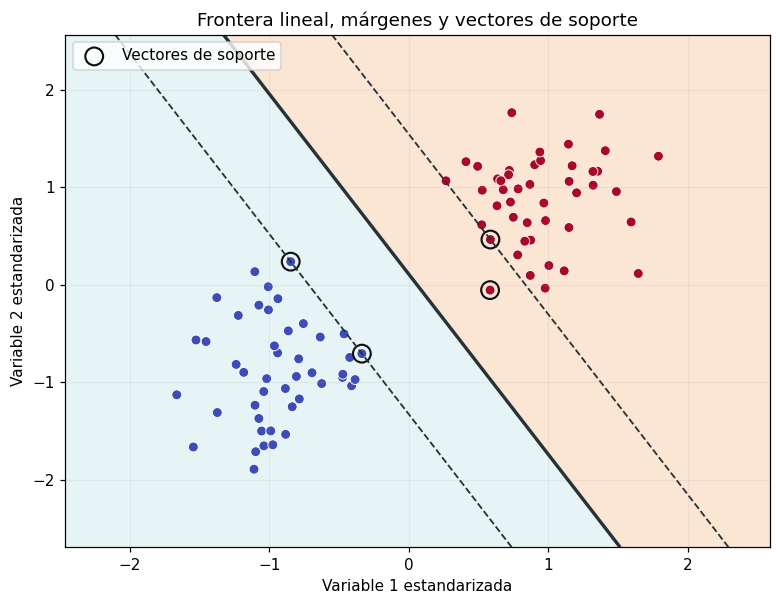

In [3]:
def dibujar_frontera_svm(
    ax,
    modelo,
    X,
    y,
    titulo,
    mostrar_margenes=True,
):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 350),
        np.linspace(y_min, y_max, 350),
    )
    grilla = np.c_[xx.ravel(), yy.ravel()]
    valores = modelo.decision_function(
        grilla
    ).reshape(xx.shape)

    ax.contourf(
        xx,
        yy,
        valores > 0,
        levels=[-0.5, 0.5, 1.5],
        colors=["#A8DADC", "#F4A261"],
        alpha=0.28,
    )

    niveles = [-1, 0, 1] if mostrar_margenes else [0]
    estilos = ["--", "-", "--"] if mostrar_margenes else ["-"]
    grosores = [1.2, 2.2, 1.2] if mostrar_margenes else [2.2]

    ax.contour(
        xx,
        yy,
        valores,
        levels=niveles,
        colors="#263238",
        linestyles=estilos,
        linewidths=grosores,
    )
    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap="coolwarm",
        edgecolor="white",
        linewidth=0.6,
        s=42,
    )
    ax.scatter(
        modelo.support_vectors_[:, 0],
        modelo.support_vectors_[:, 1],
        s=135,
        facecolors="none",
        edgecolors="#111111",
        linewidth=1.4,
        label="Vectores de soporte",
    )
    ax.set_title(titulo)
    ax.set_xlabel("Variable 1 estandarizada")
    ax.set_ylabel("Variable 2 estandarizada")
    ax.grid(alpha=0.16)


fig, ax = plt.subplots(figsize=(7.2, 5.6))
dibujar_frontera_svm(
    ax,
    svm_margen,
    X_margen_escalado,
    y_margen,
    "Frontera lineal, márgenes y vectores de soporte",
)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


La línea continua representa la frontera de decisión. Las líneas discontinuas señalan los límites del margen. Los puntos rodeados por un círculo son los **vectores de soporte**: casos cercanos a la separación que ayudan a determinar su posición.

La mayoría de los puntos queda lejos de la frontera y resulta fácil de clasificar. El modelo no necesita apoyar la separación por igual en todos ellos. En este ejemplo didáctico logra una separación perfecta, pero eso no prueba generalización porque todavía no usamos datos nuevos.


In [4]:
indices_soporte = svm_margen.support_
puntajes_soporte = svm_margen.decision_function(
    X_margen_escalado[indices_soporte]
)

pd.DataFrame({
    "indice_original": indices_soporte,
    "clase_real": y_margen[indices_soporte],
    "variable_1": X_margen[
        indices_soporte, 0
    ],
    "variable_2": X_margen[
        indices_soporte, 1
    ],
    "decision_function": puntajes_soporte,
}).round(3)


,indice_original,clase_real,variable_1,variable_2,decision_function
0,6,0,-0.823,-1.029,-1.000
1,33,0,-1.924,0.418,-1.000
2,12,1,1.165,0.766,1.000
3,72,1,1.159,-0.029,0.636


`decision_function` entrega un puntaje con signo:

- valores negativos quedan del lado de la clase `0`;
- valores positivos quedan del lado de la clase `1`;
- valores cercanos a cero están próximos a la frontera.

Las líneas del margen corresponden a puntajes cercanos a `-1` y `1`. El puntaje expresa posición respecto de la frontera, pero **no es una probabilidad**.


## 3. Controlar el margen suave mediante `C`

Los datos reales suelen contener superposición, ruido o casos ambiguos. Para observarlo crearemos un conjunto donde una separación perfecta no es razonable.

Compararemos tres valores de `C`:

- `C` pequeño: tolera más violaciones y favorece una frontera más regularizada;
- `C` intermedio: busca un equilibrio;
- `C` grande: penaliza con fuerza los errores de entrenamiento.

El ancho informado se calcula en el espacio estandarizado. Sirve para comparar estas tres fronteras, no como una distancia expresada en las unidades originales.


In [5]:
X_solapado, y_solapado = make_classification(
    n_samples=240,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=0.85,
    flip_y=0.10,
    random_state=18,
)

scaler_c = StandardScaler()
X_solapado_escalado = scaler_c.fit_transform(
    X_solapado
)

valores_c = [0.03, 1, 100]
modelos_c = {}
filas_c = []

for valor_c in valores_c:
    modelo = SVC(
        kernel="linear",
        C=valor_c,
    )
    modelo.fit(
        X_solapado_escalado,
        y_solapado,
    )
    modelos_c[valor_c] = modelo

    norma = np.linalg.norm(modelo.coef_[0])
    filas_c.append({
        "C": valor_c,
        "accuracy_entrenamiento": modelo.score(
            X_solapado_escalado,
            y_solapado,
        ),
        "vectores_soporte": (
            modelo.n_support_.sum()
        ),
        "ancho_entre_margenes": 2 / norma,
    })

resultados_c = pd.DataFrame(filas_c)
resultados_c.round(4)


,C,accuracy_entrenamiento,vectores_soporte,ancho_entre_margenes
0,0.03,0.9500,110,1.5518
1,1.00,0.9542,45,0.8183
2,100.00,0.9583,39,0.7137


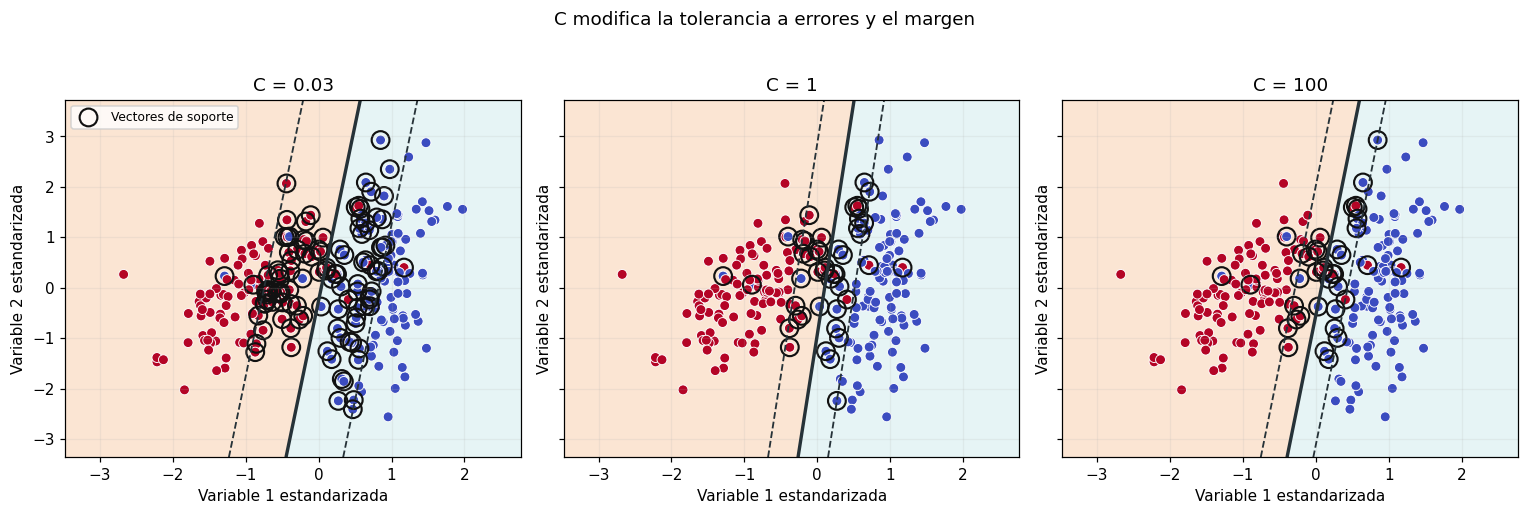

In [6]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4.5),
    sharex=True,
    sharey=True,
)

for ax, valor_c in zip(axes, valores_c):
    dibujar_frontera_svm(
        ax,
        modelos_c[valor_c],
        X_solapado_escalado,
        y_solapado,
        f"C = {valor_c}",
    )

axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle(
    "C modifica la tolerancia a errores y el margen",
    y=1.03,
)
plt.tight_layout()
plt.show()


Con `C=0.03`, 110 de los 240 puntos participan como vectores de soporte y el ancho entre márgenes es aproximadamente `1.552` en el espacio estandarizado. Con `C=100`, quedan 39 vectores de soporte y el ancho baja a `0.714`.

La accuracy de entrenamiento solo cambia de `0.950` a `0.958`. Eso ayuda a evitar una lectura mecánica: un valor extremo de `C` no se justifica solo porque ajuste levemente mejor los datos conocidos. La configuración adecuada debe elegirse por validación con datos no vistos.


## 4. Pasar de una frontera lineal a un kernel RBF

Ahora generaremos dos clases con forma circular. Una clase queda en el centro y la otra forma un anillo. Existe un patrón claro, pero ninguna recta puede separar bien ambas regiones.

Separaremos entrenamiento y validación para comparar un SVM lineal con un SVM que usa kernel RBF. Ambos pipelines incluirán exactamente el mismo escalado.


In [7]:
X_circulos, y_circulos = make_circles(
    n_samples=600,
    factor=0.38,
    noise=0.10,
    random_state=42,
)

(
    X_circulos_train,
    X_circulos_validacion,
    y_circulos_train,
    y_circulos_validacion,
) = train_test_split(
    X_circulos,
    y_circulos,
    test_size=0.30,
    random_state=42,
    stratify=y_circulos,
)

modelos_kernel = {
    "Lineal": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("modelo", SVC(
            kernel="linear",
            C=1.0,
        )),
    ]),
    "RBF": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("modelo", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
        )),
    ]),
}

filas_kernel = []

for nombre, modelo in modelos_kernel.items():
    modelo.fit(
        X_circulos_train,
        y_circulos_train,
    )
    filas_kernel.append({
        "kernel": nombre,
        "accuracy_entrenamiento": modelo.score(
            X_circulos_train,
            y_circulos_train,
        ),
        "accuracy_validacion": modelo.score(
            X_circulos_validacion,
            y_circulos_validacion,
        ),
        "F1_validacion": f1_score(
            y_circulos_validacion,
            modelo.predict(
                X_circulos_validacion
            ),
        ),
        "vectores_soporte": (
            modelo.named_steps[
                "modelo"
            ].n_support_.sum()
        ),
    })

comparacion_kernel = pd.DataFrame(filas_kernel)
comparacion_kernel.round(4)


,kernel,accuracy_entrenamiento,accuracy_validacion,F1_validacion,vectores_soporte
0,Lineal,0.6286,0.5667,0.6389,415
1,RBF,0.9952,1.0000,1.0000,43


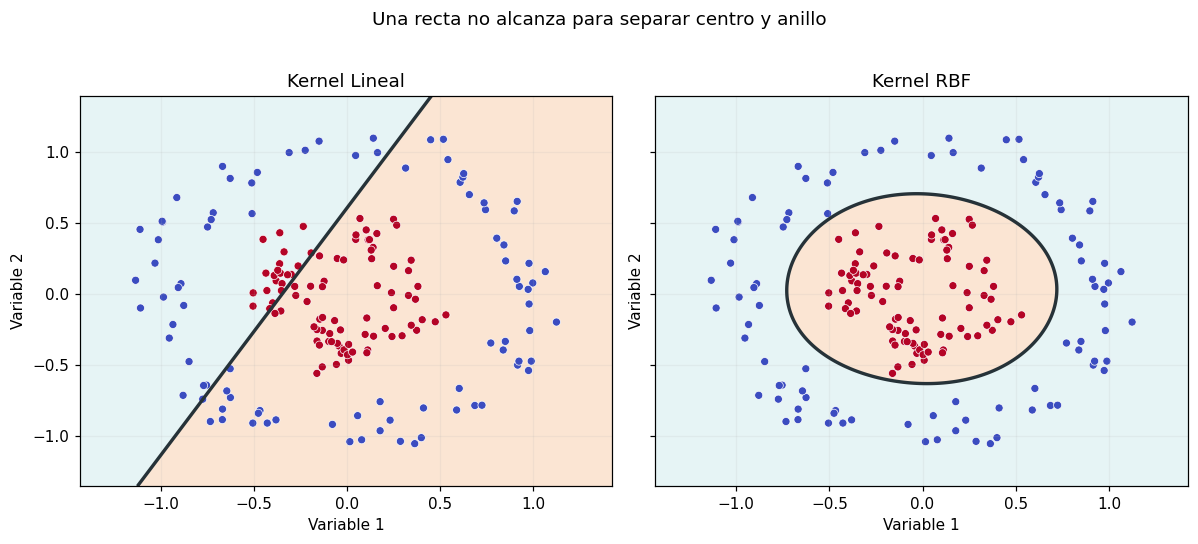

In [8]:
def dibujar_frontera_pipeline(
    ax,
    pipeline,
    X,
    y,
    titulo,
):
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 350),
        np.linspace(y_min, y_max, 350),
    )
    grilla = np.c_[xx.ravel(), yy.ravel()]
    puntajes = pipeline.decision_function(
        grilla
    ).reshape(xx.shape)

    ax.contourf(
        xx,
        yy,
        puntajes > 0,
        levels=[-0.5, 0.5, 1.5],
        colors=["#A8DADC", "#F4A261"],
        alpha=0.28,
    )
    ax.contour(
        xx,
        yy,
        puntajes,
        levels=[0],
        colors="#263238",
        linewidths=2.2,
    )
    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap="coolwarm",
        edgecolor="white",
        linewidth=0.45,
        s=28,
    )
    ax.set_title(titulo)
    ax.set_xlabel("Variable 1")
    ax.set_ylabel("Variable 2")
    ax.grid(alpha=0.14)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.8),
    sharex=True,
    sharey=True,
)

for ax, (nombre, modelo) in zip(
    axes,
    modelos_kernel.items(),
):
    dibujar_frontera_pipeline(
        ax,
        modelo,
        X_circulos_validacion,
        y_circulos_validacion,
        f"Kernel {nombre}",
    )

fig.suptitle(
    "Una recta no alcanza para separar centro y anillo",
    y=1.02,
)
plt.tight_layout()
plt.show()


El modelo lineal no puede representar la estructura circular: obtiene accuracy `0.567` y F1 `0.639` en validación. El kernel RBF construye una frontera curva y, en este ejemplo deliberadamente claro, clasifica correctamente los 180 casos de validación.

No separable linealmente no significa que no exista un patrón. Significa que una recta no alcanza. El kernel cambia el tipo de frontera que el modelo puede construir, pero esa flexibilidad también debe controlarse para evitar sobreajuste.


In [9]:
radios = np.sqrt(
    X_circulos_validacion[:, 0] ** 2
    + X_circulos_validacion[:, 1] ** 2
)

pd.DataFrame({
    "variable_1": X_circulos_validacion[:12, 0],
    "variable_2": X_circulos_validacion[:12, 1],
    "distancia_al_centro": radios[:12],
    "clase_real": y_circulos_validacion[:12],
}).sort_values(
    "distancia_al_centro"
).round(3)


,variable_1,variable_2,distancia_al_centro,clase_real
6,0.098,-0.286,0.302,1
3,-0.348,0.072,0.355,1
2,-0.380,0.091,0.391,1
0,0.161,0.425,0.454,1
8,-0.360,0.430,0.561,1
11,-0.626,-0.528,0.819,0
9,0.838,-0.396,0.927,0
5,-0.505,-0.912,1.042,0
10,0.016,-1.043,1.043,0
4,-1.108,-0.100,1.112,0


La distancia al centro deja visible una transformación útil: los puntos de la clase interior tienden a tener radios pequeños y los del anillo, radios mayores. Un kernel puede explotar relaciones de este tipo sin que debamos crear manualmente todas las columnas transformadas.

Esta tabla sirve como intuición; RBF no se limita a agregar exactamente esta única variable.


## 5. Comprobar la importancia del escalado

Retomaremos **Breast Cancer Wisconsin**. La variable objetivo original usa `0` para maligno y `1` para benigno. La invertiremos para conservar la convención de los cuadernos anteriores:

- `1`: caso maligno;
- `0`: caso benigno.

Las 30 variables están expresadas en escalas muy diferentes. Esto permite observar qué ocurre si un SVM con RBF se entrena con y sin `StandardScaler`.

> Este conjunto se utiliza con fines didácticos. Un modelo construido aquí no constituye una herramienta clínica.


In [10]:
datos_medicos = load_breast_cancer(as_frame=True)

X = datos_medicos.data.copy()
y = 1 - datos_medicos.target
y.name = "caso_maligno"

pd.DataFrame({
    "filas": [len(X)],
    "variables": [X.shape[1]],
    "casos_benignos": [(y == 0).sum()],
    "casos_malignos": [(y == 1).sum()],
    "proporcion_malignos": [y.mean()],
    "menor_desviacion": [X.std().min()],
    "mayor_desviacion": [X.std().max()],
}).round(3)


,filas,variables,casos_benignos,casos_malignos,proporcion_malignos,menor_desviacion,mayor_desviacion
0,569,30,357,212,0.373,0.003,569.357


## 6. Reservar el conjunto de prueba final

Separaremos el mismo 20% usado en los Cuadernos 21 y 22. La validación, la comparación de kernels y la búsqueda de hiperparámetros se realizarán dentro del conjunto de desarrollo. El test permanecerá reservado hasta la evaluación definitiva.


In [11]:
X_desarrollo, X_test_final, y_desarrollo, y_test_final = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=21,
        stratify=y,
    )
)

pd.DataFrame({
    "conjunto": ["Desarrollo", "Prueba final"],
    "filas": [len(X_desarrollo), len(X_test_final)],
    "proporcion_malignos": [
        y_desarrollo.mean(),
        y_test_final.mean(),
    ],
}).round(3)


,conjunto,filas,proporcion_malignos
0,Desarrollo,455,0.374
1,Prueba final,114,0.368


Hasta la evaluación final no consultaremos ninguna métrica del test. Incluso el escalado debe permanecer dentro del pipeline para que, en cada fold, sus medias y desviaciones se aprendan únicamente a partir de la porción de entrenamiento correspondiente.


In [12]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

svm_sin_escalado = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
)

svm_con_escalado = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("modelo", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
    )),
])

modelos_escalado = {
    "Sin escalado": svm_sin_escalado,
    "Con StandardScaler": svm_con_escalado,
}

filas_escalado = []

for nombre, modelo in modelos_escalado.items():
    resultados = cross_validate(
        modelo,
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring="f1",
        return_train_score=True,
        n_jobs=-1,
    )
    filas_escalado.append({
        "preprocesamiento": nombre,
        "F1_entrenamiento": (
            resultados["train_score"].mean()
        ),
        "F1_validacion": (
            resultados["test_score"].mean()
        ),
        "desviacion_F1": (
            resultados["test_score"].std()
        ),
    })

comparacion_escalado = pd.DataFrame(
    filas_escalado
)
comparacion_escalado.round(4)


,preprocesamiento,F1_entrenamiento,F1_validacion,desviacion_F1
0,Sin escalado,0.8599,0.8643,0.0214
1,Con StandardScaler,0.9843,0.9733,0.0116


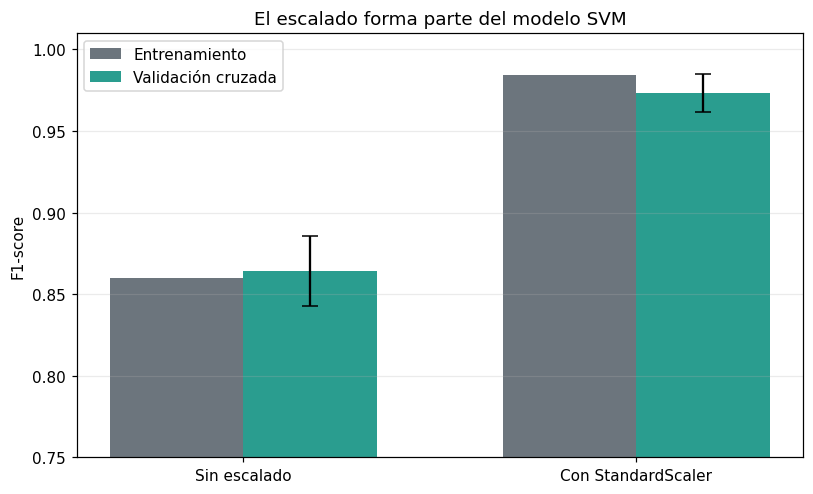

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))

x = np.arange(len(comparacion_escalado))
ancho = 0.34

ax.bar(
    x - ancho / 2,
    comparacion_escalado["F1_entrenamiento"],
    width=ancho,
    color="#6C757D",
    label="Entrenamiento",
)
ax.bar(
    x + ancho / 2,
    comparacion_escalado["F1_validacion"],
    width=ancho,
    yerr=comparacion_escalado["desviacion_F1"],
    capsize=5,
    color="#2A9D8F",
    label="Validación cruzada",
)

ax.set_xticks(x)
ax.set_xticklabels(
    comparacion_escalado["preprocesamiento"]
)
ax.set_ylim(0.75, 1.01)
ax.set_ylabel("F1-score")
ax.set_title(
    "El escalado forma parte del modelo SVM"
)
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


El mismo SVM cambia de manera importante cuando las variables se estandarizan. Sin escalado obtiene F1 promedio `0.864`; con `StandardScaler` alcanza `0.973`. Las columnas de gran magnitud dejaban de dominar la geometría por una razón puramente numérica.

No debemos escalar todo el dataset antes de la validación. El pipeline hace que el escalador se ajuste nuevamente dentro de cada fold y evita que información de la validación ingrese al entrenamiento.


## 7. Comparar una frontera lineal y una no lineal

Usaremos los mismos folds para comparar:

- regresión logística como referencia lineal conocida;
- SVM con kernel lineal;
- SVM con kernel RBF;
- Random Forest como referencia del capítulo 21.

Los tres modelos sensibles a la escala incluyen `StandardScaler`. Las configuraciones son puntos de partida, no resultados finales ajustados.


In [14]:
modelos_comparacion = {
    "Regresión logística": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("modelo", LogisticRegression(
            C=1.0,
            max_iter=5000,
            random_state=42,
        )),
    ]),
    "SVM lineal": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("modelo", SVC(
            kernel="linear",
            C=1.0,
        )),
    ]),
    "SVM RBF": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("modelo", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
        )),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    ),
}

filas_comparacion = []

for nombre, modelo in modelos_comparacion.items():
    resultados = cross_validate(
        modelo,
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1": "f1",
        },
        return_train_score=True,
        n_jobs=-1,
    )
    filas_comparacion.append({
        "modelo": nombre,
        "F1_entrenamiento": (
            resultados["train_f1"].mean()
        ),
        "F1_validacion": (
            resultados["test_f1"].mean()
        ),
        "desviacion_F1": (
            resultados["test_f1"].std()
        ),
        "accuracy_validacion": (
            resultados["test_accuracy"].mean()
        ),
    })

comparacion_modelos = pd.DataFrame(
    filas_comparacion
)
comparacion_modelos.sort_values(
    "F1_validacion",
    ascending=False,
).round(4)


,modelo,F1_entrenamiento,F1_validacion,desviacion_F1,accuracy_validacion
2,SVM RBF,0.9843,0.9733,0.0116,0.9802
1,SVM lineal,0.9873,0.9662,0.0357,0.9758
0,Regresión logística,0.9866,0.9662,0.0306,0.9758
3,Random Forest,1.0000,0.9440,0.0422,0.9582


SVM RBF obtiene F1 promedio `0.973`; SVM lineal y regresión logística alcanzan `0.966`, y Random Forest, `0.944`. Las diferencias entre los tres primeros candidatos son pequeñas en relación con la variabilidad de los folds.

Una diferencia pequeña no demuestra que el problema necesite necesariamente una frontera no lineal. Para tomar una decisión prudente debemos observar promedio, variabilidad, costo e interpretabilidad, y ajustar cada candidato bajo las mismas reglas.


## 8. Ajustar kernel, `C` y `gamma`

Realizaremos una búsqueda sobre el conjunto de desarrollo. Para el kernel lineal solo necesitamos variar `C`. Para RBF exploraremos combinaciones de `C` y `gamma`.

La grilla tiene 30 configuraciones:

- 5 valores de `C` para el kernel lineal;
- 5 valores de `C` por 5 valores de `gamma` para RBF.

Con cinco folds, esto requiere 150 entrenamientos de validación, más el reajuste final que realiza `GridSearchCV`.


In [15]:
pipeline_busqueda = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("modelo", SVC()),
])

param_grid = [
    {
        "modelo__kernel": ["linear"],
        "modelo__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "modelo__kernel": ["rbf"],
        "modelo__C": [0.01, 0.1, 1, 10, 100],
        "modelo__gamma": [
            0.001,
            0.01,
            0.03,
            0.1,
            1,
        ],
    },
]

busqueda = GridSearchCV(
    estimator=pipeline_busqueda,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    return_train_score=True,
    n_jobs=-1,
)
busqueda.fit(X_desarrollo, y_desarrollo)

pd.DataFrame({
    "resultado": [
        "Kernel elegido",
        "C elegido",
        "gamma elegido",
        "Mejor F1 de validación",
        "Configuraciones evaluadas",
        "Entrenamientos de validación",
    ],
    "valor": [
        busqueda.best_params_[
            "modelo__kernel"
        ],
        busqueda.best_params_["modelo__C"],
        busqueda.best_params_.get(
            "modelo__gamma",
            "No corresponde",
        ),
        round(busqueda.best_score_, 4),
        len(busqueda.cv_results_["params"]),
        len(busqueda.cv_results_["params"])
        * cv.get_n_splits(),
    ],
})


,resultado,valor
0,Kernel elegido,rbf
1,C elegido,10
2,gamma elegido,0.03
3,Mejor F1 de validación,0.9759
4,Configuraciones evaluadas,30
5,Entrenamientos de validación,150


In [16]:
resultados_busqueda = pd.DataFrame(
    busqueda.cv_results_
)

columnas_resultados = [
    "param_modelo__kernel",
    "param_modelo__C",
    "param_modelo__gamma",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]

resultados_busqueda[
    columnas_resultados
].sort_values(
    ["rank_test_score", "mean_test_score"],
    ascending=[True, False],
).head(10).round(4)


,param_modelo__kernel,param_modelo__C,param_modelo__gamma,mean_train_score,mean_test_score,std_test_score,rank_test_score
22,rbf,10.00,0.030,0.9881,0.9759,0.0232,1
21,rbf,10.00,0.010,0.9858,0.9724,0.0275,2
1,linear,0.10,NaN,0.9821,0.9723,0.0274,3
17,rbf,1.00,0.030,0.9843,0.9700,0.0100,4
2,linear,1.00,NaN,0.9873,0.9662,0.0357,5
3,linear,10.00,NaN,0.9918,0.9642,0.0177,6
0,linear,0.01,NaN,0.9635,0.9636,0.0074,7
25,rbf,100.00,0.001,0.9836,0.9631,0.0292,8
26,rbf,100.00,0.010,0.9956,0.9611,0.0293,9
16,rbf,1.00,0.010,0.9689,0.9605,0.0160,10


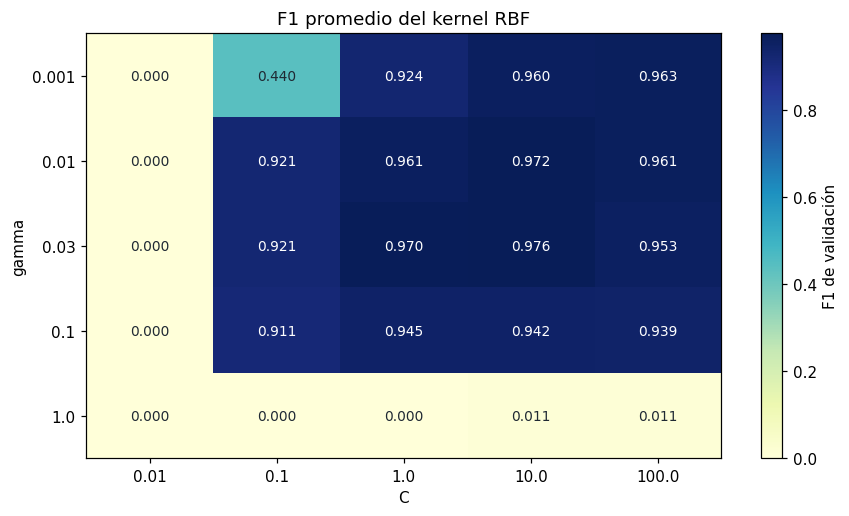

In [17]:
resultados_rbf = resultados_busqueda[
    resultados_busqueda[
        "param_modelo__kernel"
    ] == "rbf"
].copy()

tabla_c_gamma = resultados_rbf.pivot(
    index="param_modelo__gamma",
    columns="param_modelo__C",
    values="mean_test_score",
)

fig, ax = plt.subplots(figsize=(8.2, 4.8))

imagen = ax.imshow(
    tabla_c_gamma.values,
    cmap="YlGnBu",
    vmin=tabla_c_gamma.values.min(),
    vmax=tabla_c_gamma.values.max(),
    aspect="auto",
)

ax.set_xticks(
    np.arange(len(tabla_c_gamma.columns))
)
ax.set_xticklabels(tabla_c_gamma.columns)
ax.set_yticks(
    np.arange(len(tabla_c_gamma.index))
)
ax.set_yticklabels(tabla_c_gamma.index)
ax.set_xlabel("C")
ax.set_ylabel("gamma")
ax.set_title(
    "F1 promedio del kernel RBF"
)

umbral_color = (
    tabla_c_gamma.values.min()
    + tabla_c_gamma.values.max()
) / 2

for fila in range(len(tabla_c_gamma.index)):
    for columna in range(
        len(tabla_c_gamma.columns)
    ):
        valor = tabla_c_gamma.iloc[
            fila, columna
        ]
        color = (
            "white"
            if valor >= umbral_color
            else "#1F2933"
        )
        ax.text(
            columna,
            fila,
            f"{valor:.3f}",
            ha="center",
            va="center",
            color=color,
            fontsize=9,
        )

fig.colorbar(
    imagen,
    ax=ax,
    label="F1 de validación",
)
plt.tight_layout()
plt.show()


La tabla y el mapa de calor muestran que `C` y `gamma` interactúan. La mejor celda de esta grilla usa kernel RBF, `C=10` y `gamma=0.03`, con F1 promedio `0.9759`. La siguiente configuración queda en `0.9724`: una diferencia pequeña que no autoriza a presentar la primera como universalmente superior.

Combinaciones con ambos valores muy bajos producen una frontera demasiado rígida y subajustan. Un `gamma` alto vuelve la influencia más local; combinado con un `C` grande puede elevar el ajuste al entrenamiento sin mejorar la validación.

`best_params_` señala la mejor configuración dentro de esta grilla y de estos folds. No prueba que esos valores sean universales ni que una diferencia mínima sea sustantiva. El test todavía no intervino en ninguna decisión.


## 9. Examinar puntajes y vectores de soporte

`GridSearchCV` reajusta automáticamente el mejor pipeline sobre todo el conjunto de desarrollo. Antes de abrir el test, observaremos dos propiedades usando únicamente desarrollo:

- cuántos casos quedan como vectores de soporte;
- qué casos reciben puntajes de decisión cercanos a cero mediante predicciones fuera de fold.

`cross_val_predict` entrena cada predicción con los otros folds. Por eso, los puntajes siguientes no son predicciones del mismo modelo que ya vio esas filas.


In [18]:
mejor_pipeline = busqueda.best_estimator_
mejor_svm = mejor_pipeline.named_steps["modelo"]

resumen_soporte = pd.DataFrame({
    "clase": [0, 1, "Total"],
    "vectores_soporte": [
        mejor_svm.n_support_[0],
        mejor_svm.n_support_[1],
        mejor_svm.n_support_.sum(),
    ],
    "proporcion_desarrollo": [
        mejor_svm.n_support_[0]
        / (y_desarrollo == 0).sum(),
        mejor_svm.n_support_[1]
        / (y_desarrollo == 1).sum(),
        mejor_svm.n_support_.sum()
        / len(y_desarrollo),
    ],
})

resumen_soporte.round(3)


,clase,vectores_soporte,proporcion_desarrollo
0,0,42,0.147
1,1,41,0.241
2,Total,83,0.182


In [19]:
puntajes_fuera_fold = cross_val_predict(
    mejor_pipeline,
    X_desarrollo,
    y_desarrollo,
    cv=cv,
    method="decision_function",
    n_jobs=-1,
)

predicciones_fuera_fold = (
    puntajes_fuera_fold >= 0
).astype(int)

casos_cercanos = pd.DataFrame({
    "indice": X_desarrollo.index,
    "clase_real": y_desarrollo.to_numpy(),
    "puntaje_decision": puntajes_fuera_fold,
    "clase_predicha": predicciones_fuera_fold,
    "distancia_a_cero": np.abs(
        puntajes_fuera_fold
    ),
}).sort_values(
    "distancia_a_cero"
).head(12)

casos_cercanos.round(4)


,indice,clase_real,puntaje_decision,clase_predicha,distancia_a_cero
308,81,0,0.0536,1,0.0536
190,414,1,0.1225,1,0.1225
440,526,0,-0.1348,0,0.1348
333,514,1,0.1598,1,0.1598
429,197,1,0.1664,1,0.1664
288,152,0,0.1704,1,0.1704
166,461,1,0.1727,1,0.1727
404,421,0,-0.1884,0,0.1884
162,136,0,-0.2265,0,0.2265
393,541,0,0.2272,1,0.2272


El modelo reajustado utiliza 83 vectores de soporte, alrededor del `18.2%` del conjunto de desarrollo. Los casos con puntajes cercanos a cero están próximos a la frontera estimada por sus respectivos modelos fuera de fold. Son casos útiles para revisar porque pequeñas variaciones podrían cambiar la clase predicha.

No debemos llamar “confianza” o “probabilidad” a la magnitud de `decision_function`. El puntaje permite ordenar casos respecto de la frontera, pero no tiene una interpretación probabilística directa.


## 10. Evaluar una vez sobre el test final

La configuración ya quedó fijada mediante validación. Ahora entrenaremos el mejor pipeline con todo el conjunto de desarrollo y consultaremos el test reservado una única vez.


In [20]:
prediccion_final = mejor_pipeline.predict(
    X_test_final
)
puntaje_final = mejor_pipeline.decision_function(
    X_test_final
)

metricas_finales = pd.DataFrame({
    "metrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
    ],
    "valor": [
        accuracy_score(
            y_test_final,
            prediccion_final,
        ),
        precision_score(
            y_test_final,
            prediccion_final,
        ),
        recall_score(
            y_test_final,
            prediccion_final,
        ),
        f1_score(
            y_test_final,
            prediccion_final,
        ),
    ],
})

metricas_finales.round(4)


,metrica,valor
0,Accuracy,0.9649
1,Precision,0.9750
2,Recall,0.9286
3,F1-score,0.9512


array([[71,  1],
       [ 3, 39]])

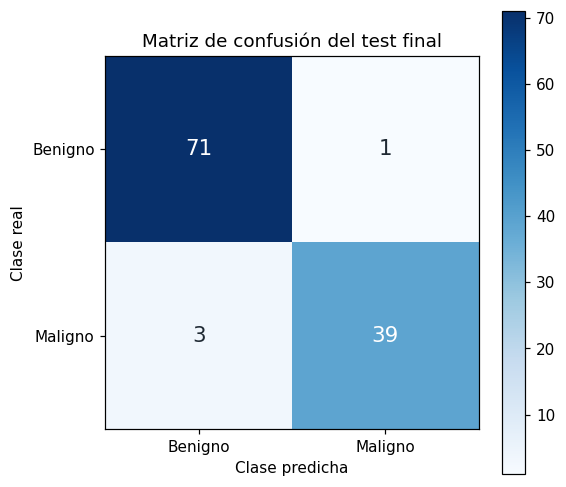

In [21]:
matriz_final = confusion_matrix(
    y_test_final,
    prediccion_final,
)

fig, ax = plt.subplots(figsize=(5.4, 4.8))

imagen = ax.imshow(
    matriz_final,
    cmap="Blues",
)

for fila in range(2):
    for columna in range(2):
        valor = matriz_final[fila, columna]
        color = (
            "white"
            if valor > matriz_final.max() / 2
            else "#1F2933"
        )
        ax.text(
            columna,
            fila,
            str(valor),
            ha="center",
            va="center",
            color=color,
            fontsize=14,
        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Benigno", "Maligno"])
ax.set_yticklabels(["Benigno", "Maligno"])
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
ax.set_title("Matriz de confusión del test final")
fig.colorbar(imagen, ax=ax)
plt.tight_layout()
plt.show()

matriz_final


In [22]:
errores_test = pd.DataFrame({
    "indice": X_test_final.index,
    "clase_real": y_test_final.to_numpy(),
    "clase_predicha": prediccion_final,
    "puntaje_decision": puntaje_final,
})

errores_test[
    errores_test["clase_real"]
    != errores_test["clase_predicha"]
].assign(
    distancia_a_cero=lambda df: np.abs(
        df["puntaje_decision"]
    )
).sort_values(
    "distancia_a_cero"
).round(4)


,indice,clase_real,clase_predicha,puntaje_decision,distancia_a_cero
6,263,1,0,-0.0082,0.0082
77,205,1,0,-0.0511,0.0511
16,68,0,1,0.0511,0.0511
0,255,1,0,-0.9995,0.9995


El modelo obtiene accuracy `0.965` y F1 `0.951`. Clasifica correctamente 71 casos benignos y 39 malignos, produce una falsa alarma y deja sin detectar tres casos malignos. El resultado de test es algo menor que el promedio de validación, algo esperable cuando se evalúa una muestra nueva.

El desempeño es sólido para este ejercicio, pero no convierte el modelo en una herramienta clínica. Un caso maligno no detectado y una falsa alarma tienen consecuencias diferentes, y F1 no reemplaza esa discusión.

Los puntajes de los errores muestran de qué lado de la frontera quedaron. Un error con puntaje cercano a cero era limítrofe; uno alejado de cero indica que el modelo lo ubicó con claridad del lado incorrecto. Ninguno de esos valores es una probabilidad.


## 11. Probabilidades y costo computacional

`SVC` no calcula probabilidades por defecto. Su salida natural es la clase y el puntaje de `decision_function`. Es posible activar:

```python
SVC(probability=True)
```

pero ese cálculo agrega trabajo durante el entrenamiento y no garantiza por sí solo probabilidades perfectamente calibradas. Si el problema necesita ordenar riesgos, ajustar umbrales o comunicar probabilidades, debemos evaluar ese requisito de manera específica y comparar con modelos que entregan probabilidades más directamente.

El costo también importa al crecer la cantidad de filas. Los kernels no lineales pueden volverse lentos en datasets grandes porque dependen de relaciones entre observaciones. Un SVM lineal suele escalar mejor; para volúmenes muy grandes puede ser más práctico usar `LinearSVC` u otros modelos lineales.


## 12. Actividad breve

La siguiente celda compara seis configuraciones sobre el conjunto de desarrollo. Mantiene el escalado dentro del pipeline y usa tres folds para que la actividad sea rápida.

Podés modificar `configuraciones_actividad`, agregar otros valores de `C` o `gamma` y explicar si una mejora pequeña justifica una frontera más flexible. No vuelvas a usar el test para decidir.


In [23]:
configuraciones_actividad = [
    ("Lineal suave", "linear", 0.1, "scale"),
    ("Lineal estricto", "linear", 10, "scale"),
    ("RBF amplio", "rbf", 1, 0.001),
    ("RBF moderado", "rbf", 1, 0.01),
    ("RBF local", "rbf", 1, 0.1),
    ("RBF flexible", "rbf", 10, 0.1),
]

cv_actividad = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=11,
)
filas_actividad = []

for nombre, kernel, valor_c, gamma in (
    configuraciones_actividad
):
    pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("modelo", SVC(
            kernel=kernel,
            C=valor_c,
            gamma=gamma,
        )),
    ])
    resultados = cross_validate(
        pipeline,
        X_desarrollo,
        y_desarrollo,
        cv=cv_actividad,
        scoring="f1",
        return_train_score=True,
        n_jobs=-1,
    )
    filas_actividad.append({
        "configuracion": nombre,
        "kernel": kernel,
        "C": valor_c,
        "gamma": gamma,
        "F1_entrenamiento": (
            resultados["train_score"].mean()
        ),
        "F1_validacion": (
            resultados["test_score"].mean()
        ),
        "desviacion_F1": (
            resultados["test_score"].std()
        ),
    })

pd.DataFrame(filas_actividad).sort_values(
    "F1_validacion",
    ascending=False,
).round(4)


,configuracion,kernel,C,gamma,F1_entrenamiento,F1_validacion,desviacion_F1
0,Lineal suave,linear,0.1,scale,0.9727,0.9728,0.0132
1,Lineal estricto,linear,10.0,scale,0.9941,0.9586,0.0110
3,RBF moderado,rbf,1.0,0.01,0.9650,0.9570,0.0195
5,RBF flexible,rbf,10.0,0.1,1.0000,0.9399,0.0117
4,RBF local,rbf,1.0,0.1,0.9881,0.9394,0.0076
2,RBF amplio,rbf,1.0,0.001,0.9290,0.9082,0.0505


## 13. Ventajas y limitaciones

SVM combina una idea geométrica clara con fronteras potentes. Puede funcionar bien en datasets pequeños o medianos, en espacios con muchas variables informativas y en problemas donde interesa comparar una separación lineal con otra no lineal. El margen y los kernels ofrecen una familia flexible dentro de un mismo enfoque.

Esa potencia exige cuidado. SVM es sensible al escalado, a `C` y a `gamma`; los kernels no lineales pueden ser costosos con muchas filas; una frontera RBF no siempre es fácil de explicar; y las probabilidades requieren tratamiento adicional. También sigue siendo vulnerable a ruido, fuga de datos, variables irrelevantes y objetivos mal formulados.

Si una regresión logística obtiene resultados parecidos y la interpretación o las probabilidades son importantes, el modelo más simple puede ser preferible. Si el dataset es enorme, el costo puede descartar un kernel no lineal aunque su métrica sea buena.


## 14. Síntesis

En este cuaderno:

- visualizamos una frontera lineal, sus márgenes y sus vectores de soporte;
- usamos `decision_function` para ubicar casos respecto de la frontera;
- observamos cómo `C` modifica la tolerancia a errores;
- comparamos un kernel lineal con RBF sobre datos circulares;
- relacionamos una transformación radial con la intuición de los kernels;
- comprobamos el efecto del escalado;
- mantuvimos `StandardScaler` dentro del pipeline;
- comparamos SVM con modelos conocidos usando los mismos folds;
- ajustamos kernel, `C` y `gamma` sin consultar el test;
- revisamos los vectores de soporte y los casos limítrofes;
- realizamos una única evaluación final;
- distinguimos puntajes de decisión de probabilidades.

SVM no busca únicamente una frontera que clasifique. Busca una separación apoyada en los casos críticos y controlada por el margen. Los kernels amplían el tipo de fronteras posibles, pero el buen resultado depende del preprocesamiento, de la validación y de una elección prudente de complejidad.


## Para pensar

1. ¿Por qué los puntos alejados de la frontera suelen influir menos que los vectores de soporte?
2. ¿Qué riesgo aparece al combinar un `C` alto con un `gamma` alto?
3. ¿Por qué el escalado debe estar dentro del pipeline durante la validación cruzada?
4. ¿Qué evidencia necesitarías para preferir RBF frente a un SVM lineal?
5. ¿Por qué `decision_function` no debe comunicarse como si fuera una probabilidad?


---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
